In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
file_path="/content/drive/MyDrive/Shopify.csv"

In [9]:
import pandas as pd
df = pd.read_csv(file_path)
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-05-20,17.000000,17.000000,17.000000,17.000000,17.000000,0
1,2015-05-21,28.000000,28.740000,24.110001,25.680000,25.680000,12303900
2,2015-05-22,26.070000,31.100000,26.000000,28.309999,28.309999,2841200
3,2015-05-26,29.799999,30.340000,29.080000,29.650000,29.650000,820200
4,2015-05-27,30.670000,30.809999,27.000000,27.500000,27.500000,797600


In [10]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 Rows:")
display(df.head())

Shape: (1766, 7)

Columns:
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

Data Types:
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

First 5 Rows:


,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-05-20,17.000000,17.000000,17.000000,17.000000,17.000000,0
1,2015-05-21,28.000000,28.740000,24.110001,25.680000,25.680000,12303900
2,2015-05-22,26.070000,31.100000,26.000000,28.309999,28.309999,2841200
3,2015-05-26,29.799999,30.340000,29.080000,29.650000,29.650000,820200
4,2015-05-27,30.670000,30.809999,27.000000,27.500000,27.500000,797600


In [11]:
print(df.isnull().sum())

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [12]:
price_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
for column in price_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

In [13]:
df = df.dropna(subset=price_columns)

In [14]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', utc=True)
df = df.dropna(subset=['Date'])
df = df.sort_values('Date')
df = df.reset_index(drop=True)
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-05-20 00:00:00+00:00,17.000000,17.000000,17.000000,17.000000,17.000000,0
1,2015-05-21 00:00:00+00:00,28.000000,28.740000,24.110001,25.680000,25.680000,12303900
2,2015-05-22 00:00:00+00:00,26.070000,31.100000,26.000000,28.309999,28.309999,2841200
3,2015-05-26 00:00:00+00:00,29.799999,30.340000,29.080000,29.650000,29.650000,820200
4,2015-05-27 00:00:00+00:00,30.670000,30.809999,27.000000,27.500000,27.500000,797600


In [15]:
df['Daily_Delta'] = df['Close'] - df['Open']

In [16]:
print(df[['Date', 'Open', 'Close', 'Daily_Delta']].head())

                       Date       Open      Close  Daily_Delta
0 2015-05-20 00:00:00+00:00  17.000000  17.000000     0.000000
1 2015-05-21 00:00:00+00:00  28.000000  25.680000    -2.320000
2 2015-05-22 00:00:00+00:00  26.070000  28.309999     2.239999
3 2015-05-26 00:00:00+00:00  29.799999  29.650000    -0.149999
4 2015-05-27 00:00:00+00:00  30.670000  27.500000    -3.170000


In [17]:
df['Daily_Return'] = df['Close'].pct_change() * 100

In [18]:
print(df[['Date', 'Open', 'Close', 'Daily_Delta', 'Daily_Return']].head())

                       Date       Open      Close  Daily_Delta  Daily_Return
0 2015-05-20 00:00:00+00:00  17.000000  17.000000     0.000000           NaN
1 2015-05-21 00:00:00+00:00  28.000000  25.680000    -2.320000     51.058824
2 2015-05-22 00:00:00+00:00  26.070000  28.309999     2.239999     10.241429
3 2015-05-26 00:00:00+00:00  29.799999  29.650000    -0.149999      4.733313
4 2015-05-27 00:00:00+00:00  30.670000  27.500000    -3.170000     -7.251265


In [19]:
print(df[['Date', 'Close', 'Daily_Return']].head())

                       Date      Close  Daily_Return
0 2015-05-20 00:00:00+00:00  17.000000           NaN
1 2015-05-21 00:00:00+00:00  25.680000     51.058824
2 2015-05-22 00:00:00+00:00  28.309999     10.241429
3 2015-05-26 00:00:00+00:00  29.650000      4.733313
4 2015-05-27 00:00:00+00:00  27.500000     -7.251265


In [20]:
print(df.columns.tolist())

['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily_Delta', 'Daily_Return']


In [21]:
average_volume = df['Volume'].mean()
print("Average Trading Volume:", average_volume)

Average Trading Volume: 1703854.3346545866


In [22]:
df['Volume_MA_20'] = df['Volume'].rolling(20).mean()
print(df[['Date', 'Volume', 'Volume_MA_20']].head(25))

                        Date    Volume  Volume_MA_20
0  2015-05-20 00:00:00+00:00         0           NaN
1  2015-05-21 00:00:00+00:00  12303900           NaN
2  2015-05-22 00:00:00+00:00   2841200           NaN
3  2015-05-26 00:00:00+00:00    820200           NaN
4  2015-05-27 00:00:00+00:00    797600           NaN
5  2015-05-28 00:00:00+00:00    400000           NaN
6  2015-05-29 00:00:00+00:00    255400           NaN
7  2015-06-01 00:00:00+00:00    256900           NaN
8  2015-06-02 00:00:00+00:00    379800           NaN
9  2015-06-03 00:00:00+00:00    302400           NaN
10 2015-06-04 00:00:00+00:00    322600           NaN
11 2015-06-05 00:00:00+00:00    129400           NaN
12 2015-06-08 00:00:00+00:00    280900           NaN
13 2015-06-09 00:00:00+00:00    337500           NaN
14 2015-06-10 00:00:00+00:00    273400           NaN
15 2015-06-11 00:00:00+00:00    460600           NaN
16 2015-06-12 00:00:00+00:00    847400           NaN
17 2015-06-15 00:00:00+00:00   1694300        

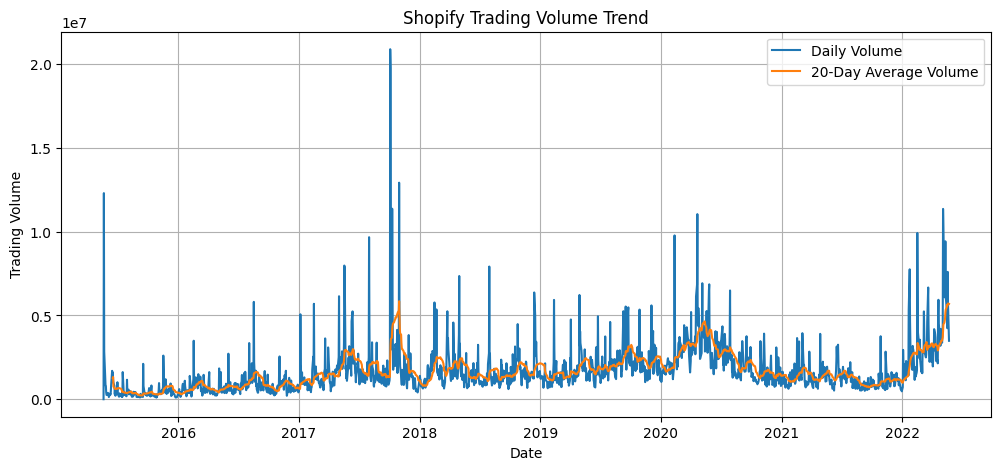

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(df['Date'], df['Volume'], label='Daily Volume')
plt.plot(df['Date'], df['Volume_MA_20'], label='20-Day Average Volume')

plt.title('Shopify Trading Volume Trend')
plt.xlabel('Date')
plt.ylabel('Trading Volume')

plt.legend()
plt.grid()

plt.show()

In [24]:
import pandas as pd
import os

# Automatically reconstruct df if it was cleared from memory
if 'df' not in globals():
    file_path = "/content/drive/MyDrive/Shopify.csv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
    else:
        raise FileNotFoundError(f"Variable 'df' is missing and file not found at {file_path}. Please mount Google Drive.")

volume_mean = df['Volume'].mean()
volume_std = df['Volume'].std()

print("Average Trading Volume:", volume_mean)
print("Volume Standard Deviation:", volume_std)

Average Trading Volume: 1703854.3346545866
Volume Standard Deviation: 1526797.611132706


In [26]:
high_volume_days = df[
    df['Volume'] > volume_mean + 2 * volume_std
]

print("Anomalous Trading Days:")

display(
    high_volume_days[
        ['Date', 'Close', 'Volume']
    ]
)

Anomalous Trading Days:


,Date,Close,Volume
1,2015-05-21 00:00:00+00:00,25.680000,12303900
314,2016-08-17 00:00:00+00:00,38.740002,5811300
411,2017-01-05 00:00:00+00:00,47.680000,5070200
439,2017-02-15 00:00:00+00:00,60.610001,5696900
491,2017-05-02 00:00:00+00:00,82.980003,6148400
...,...,...,...
1758,2022-05-12 00:00:00+00:00,353.510010,9427400
1759,2022-05-13 00:00:00+00:00,402.480011,6143000
1760,2022-05-16 00:00:00+00:00,359.950012,5413400
1763,2022-05-19 00:00:00+00:00,391.329987,7601800


In [27]:
print("Number of Anomalous Trading Days:", len(high_volume_days))

Number of Anomalous Trading Days: 64


In [28]:
returns = df['Daily_Return'].dropna()

print("Mean Return:", returns.mean())
print("Variance:", returns.var())
print("Standard Deviation:", returns.std())

Mean Return: 0.24450494868283584
Variance: 14.382008908886839
Standard Deviation: 3.7923619169175873


In [29]:
print(df['Daily_Return'].describe())

count    1765.000000
mean        0.244505
std         3.792362
min       -17.551800
25%        -1.580956
50%         0.243834
75%         2.107496
max        51.058824
Name: Daily_Return, dtype: float64


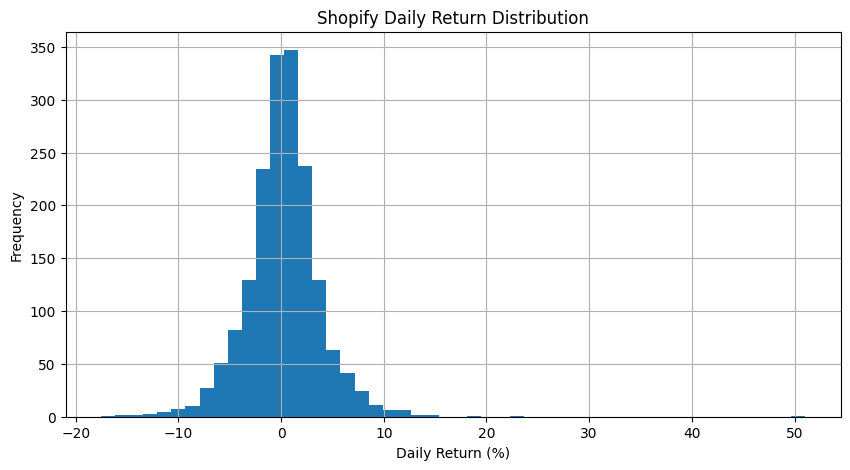

In [30]:
plt.figure(figsize=(10, 5))

plt.hist(
    df['Daily_Return'].dropna(),
    bins=50
)

plt.title('Shopify Daily Return Distribution')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')

plt.grid()

plt.show()

In [31]:
print("Final Dataset:")

display(df.head())

Final Dataset:


,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Delta,Daily_Return,Volume_MA_20
0,2015-05-20 00:00:00+00:00,17.000000,17.000000,17.000000,17.000000,17.000000,0,0.000000,NaN,NaN
1,2015-05-21 00:00:00+00:00,28.000000,28.740000,24.110001,25.680000,25.680000,12303900,-2.320000,51.058824,NaN
2,2015-05-22 00:00:00+00:00,26.070000,31.100000,26.000000,28.309999,28.309999,2841200,2.239999,10.241429,NaN
3,2015-05-26 00:00:00+00:00,29.799999,30.340000,29.080000,29.650000,29.650000,820200,-0.149999,4.733313,NaN
4,2015-05-27 00:00:00+00:00,30.670000,30.809999,27.000000,27.500000,27.500000,797600,-3.170000,-7.251265,NaN


In [32]:
print("Final Dataset:")

display(df.head())

Final Dataset:


,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Delta,Daily_Return,Volume_MA_20
0,2015-05-20 00:00:00+00:00,17.000000,17.000000,17.000000,17.000000,17.000000,0,0.000000,NaN,NaN
1,2015-05-21 00:00:00+00:00,28.000000,28.740000,24.110001,25.680000,25.680000,12303900,-2.320000,51.058824,NaN
2,2015-05-22 00:00:00+00:00,26.070000,31.100000,26.000000,28.309999,28.309999,2841200,2.239999,10.241429,NaN
3,2015-05-26 00:00:00+00:00,29.799999,30.340000,29.080000,29.650000,29.650000,820200,-0.149999,4.733313,NaN
4,2015-05-27 00:00:00+00:00,30.670000,30.809999,27.000000,27.500000,27.500000,797600,-3.170000,-7.251265,NaN


In [33]:
print("Missing Values:")

print(df.isnull().sum())

Missing Values:
Date             0
Open             0
High             0
Low              0
Close            0
Adj Close        0
Volume           0
Daily_Delta      0
Daily_Return     1
Volume_MA_20    19
dtype: int64
